# CS4452 Assignment 3: Anomaly Detection

### 

##### Dependencies & Modules

In [12]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from sklearn.metrics import roc_auc_score, accuracy_score


In [13]:
# Use seed 42 as required by the assignment
torch.manual_seed(42)
np.random.seed(42)

class ColorMNIST(Dataset):
    def __init__(self, root, train=True, transform=None, target_transform=None, download=False):
        self.mnist = datasets.MNIST(root, train=train, download=download)
        self.transform = transform

    def __getitem__(self, index):
        img, target = self.mnist[index]
        img = np.array(img)
        
        # Colorization logic from practice code
        colored_img = np.zeros((3, 28, 28), dtype=np.float32)
        color = np.random.choice([0, 1, 2])
        colored_img[color, :, :] = img / 255.0
        
        if self.transform:
            colored_img = torch.from_numpy(colored_img)
        
        return colored_img, target

    def __len__(self):
        return len(self.mnist)

#### MNIST dataset


In [14]:
mnist_transform = transforms.Compose([
    transforms.ToTensor()
])
train_mnist = MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_transform
)

test_mnist = MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_transform
)

### Part A: Autoencoder Training

Starting training...
Epoch [1/5], Loss: 0.0476
Epoch [2/5], Loss: 0.0070
Epoch [3/5], Loss: 0.0040
Epoch [4/5], Loss: 0.0030
Epoch [5/5], Loss: 0.0025


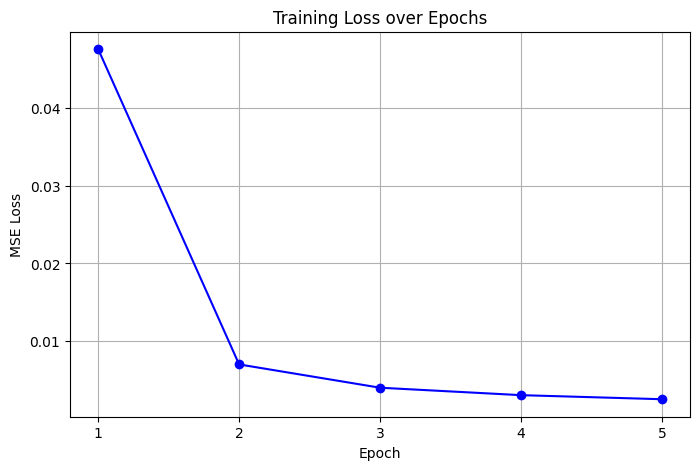

In [15]:


# 1. Define the ConvAutoencoder
class ConvAutoencoder(nn.Module):
    def __init__(self, feature_dim=128):
        super().__init__()

        # Encoder
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # (B, 3, 28, 28) -> (B, 32, 14, 14)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> (B, 64, 7, 7)
            nn.ReLU()
        )

        self.encoder_flatten = nn.Flatten()
        self.encoder_fc = nn.Linear(64 * 7 * 7, feature_dim)

        # Decoder
        self.decoder_fc = nn.Linear(feature_dim, 64 * 7 * 7)
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # -> (B, 32, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),   # -> (B, 3, 28, 28)
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_cnn(x)
        x = self.encoder_flatten(x)
        z = self.encoder_fc(x)
        return z

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 64, 7, 7)
        x = self.decoder_cnn(x)
        return x

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon

# 2. Setup Device, Model, DataLoader, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

ae_model = ConvAutoencoder(feature_dim=128).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)

# Use standard MNIST as requested
train_loader = DataLoader(train_mnist, batch_size=256, shuffle=True)

# 3. Training Loop
num_epochs = 5
epoch_losses = []

print("Starting training...")
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, _ in train_loader:
        # Repeat the 1-channel MNIST to 3 channels to match the provided model
        images = images.repeat(1, 3, 1, 1).to(device) 
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = ae_model(images)
        loss = criterion(outputs, images)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

# 4. Plot the training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-', color='b')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.xticks(range(1, num_epochs + 1))
plt.grid(True)
plt.show()

### Part B: Reconstruction Error Analysis

Average Reconstruction Error (MNIST): 0.002281
Average Reconstruction Error (ColorMNIST): 0.028419


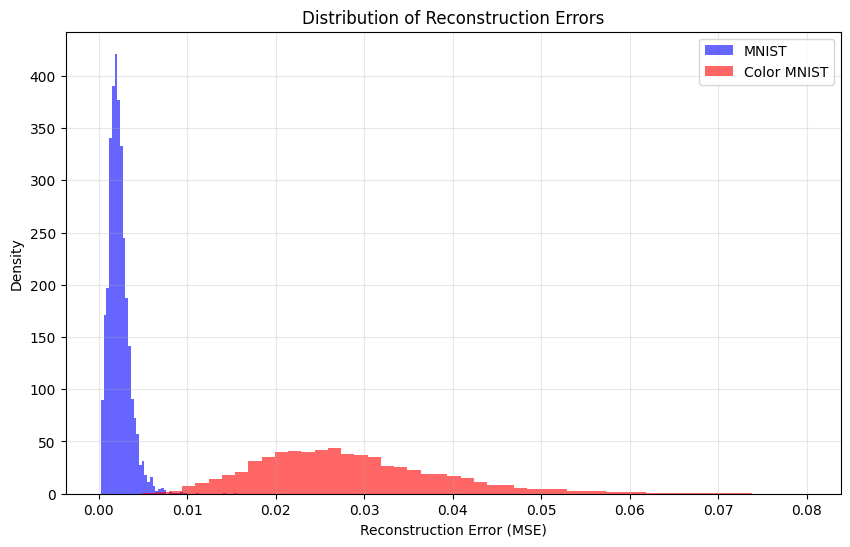

In [16]:

test_loader_mnist = DataLoader(test_mnist, batch_size=256, shuffle=False)
test_color_mnist = ColorMNIST(root="./data", train=False, download=True, transform=True)
test_loader_color = DataLoader(test_color_mnist, batch_size=256, shuffle=False)

def evaluate_reconstruction_errors(model, dataloader, repeat_channels=False):
    model.eval()
    all_errors = []
    with torch.no_grad():
        for images, _ in dataloader:
            if repeat_channels:
                images = images.repeat(1, 3, 1, 1)
            images = images.to(device)
            reconstructed = model(images)
            mse_per_image = torch.mean((images - reconstructed) ** 2, dim=[1, 2, 3])
            all_errors.extend(mse_per_image.cpu().numpy())
    return np.array(all_errors)

mnist_errors = evaluate_reconstruction_errors(ae_model, test_loader_mnist, repeat_channels=True)
color_errors = evaluate_reconstruction_errors(ae_model, test_loader_color, repeat_channels=False)

avg_mnist_error = np.mean(mnist_errors)
avg_color_error = np.mean(color_errors)

print(f"Average Reconstruction Error (MNIST): {avg_mnist_error:.6f}")
print(f"Average Reconstruction Error (ColorMNIST): {avg_color_error:.6f}")

plt.figure(figsize=(10, 6))
plt.hist(mnist_errors, bins=50, alpha=0.6, label='MNIST', color='blue', density=True)
plt.hist(color_errors, bins=50, alpha=0.6, label='Color MNIST', color='red', density=True)
plt.title('Distribution of Reconstruction Errors')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

### Part C: Anomaly Detection

In [17]:
# 1. Create true labels: 0 for normal (MNIST), 1 for anomaly (ColorMNIST)
true_labels_mnist = np.zeros(len(mnist_errors))
true_labels_color = np.ones(len(color_errors))

# Combine the labels and the reconstruction errors (scores)
y_true = np.concatenate([true_labels_mnist, true_labels_color])
y_scores = np.concatenate([mnist_errors, color_errors])

# 2. Compute the AUROC
auroc = roc_auc_score(y_true, y_scores)
print(f"AUROC: {auroc:.4f}")

# 3. Define the threshold as the 95th percentile of MNIST reconstruction errors
threshold = np.percentile(mnist_errors, 95)
print(f"Anomaly Threshold (95th percentile of MNIST): {threshold:.6f}")

# 4. Classify based on threshold (error > threshold -> anomaly, else -> normal)
y_pred = (y_scores > threshold).astype(int)

# 5. Report detection accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Detection Accuracy: {accuracy:.4f}")

AUROC: 1.0000
Anomaly Threshold (95th percentile of MNIST): 0.004376
Detection Accuracy: 0.9750


### Part D: Visualization

### Part E: Analysis 